In [6]:
# How does value change over time => line plot, area plot
# How is one numeric variable distributed => Historgram, KDE, ECDF, boxplot
# How do two numeric variable related ? Scatter, regression plot, hexbin
# How does a numeric variable differ by category ?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

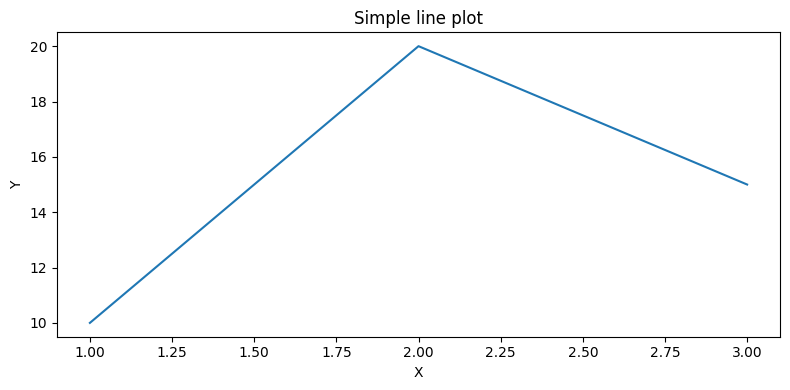

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([1, 2, 3], [10, 20, 15])
ax.set_title("Simple line plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
fig.tight_layout()
plt.show()

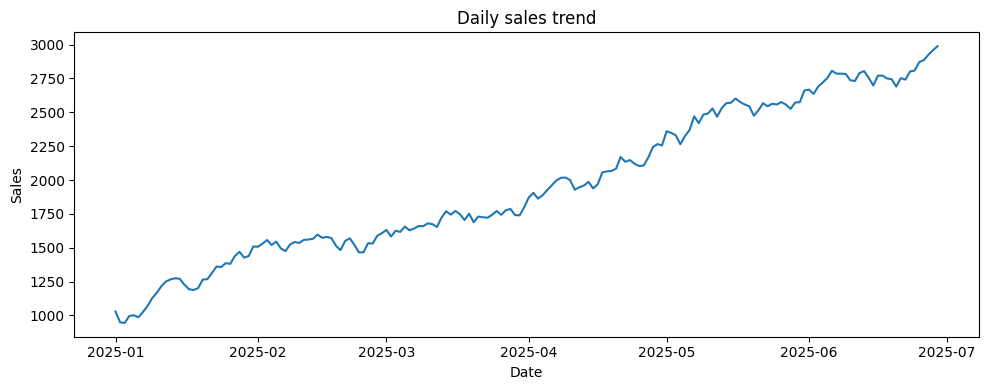

In [8]:
rng = np.random.default_rng(42)

n = 500

df = pd.DataFrame({
    "age": rng.normal(35, 10, n).clip(18, 70),
    "income": rng.normal(80000, 25000, n).clip(20000, 200000),
    "experience": rng.normal(8, 5, n).clip(0, 35),
    "score": rng.normal(70, 12, n).clip(0, 100),
    "segment": rng.choice(["A", "B", "C"], size=n, p=[0.45, 0.35, 0.20]),
    "churned": rng.choice([0, 1], size=n, p=[0.75, 0.25])
})

df["spend"] = (
    200
    + df["income"] * 0.004
    + df["score"] * 2
    + rng.normal(0, 80, n)
)

dates = pd.date_range("2025-01-01", periods=180, freq="D")

ts = pd.DataFrame({
    "date": dates,
    "sales": 1000 + np.cumsum(rng.normal(5, 40, len(dates)))
})

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(ts["date"], ts["sales"])
ax.set_title("Daily sales trend")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

fig.tight_layout()
plt.show()

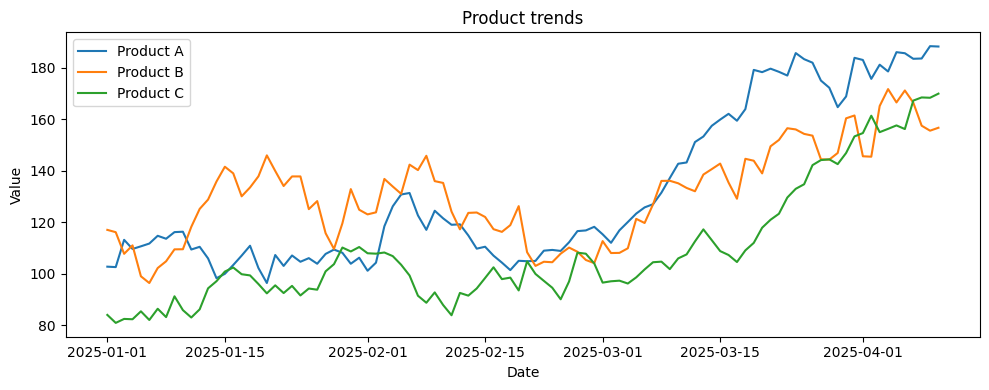

In [9]:
dates = pd.date_range("2025-01-01", periods=100, freq="D")

trend_df = pd.DataFrame({
    "date": dates,
    "product_A": 100 + np.cumsum(rng.normal(1.0, 5, len(dates))),
    "product_B": 120 + np.cumsum(rng.normal(0.5, 7, len(dates))),
    "product_C": 90 + np.cumsum(rng.normal(1.5, 4, len(dates))),
})

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(trend_df["date"], trend_df["product_A"], label="Product A")
ax.plot(trend_df["date"], trend_df["product_B"], label="Product B")
ax.plot(trend_df["date"], trend_df["product_C"], label="Product C")

ax.set_title("Product trends")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend()

fig.tight_layout()
plt.show()

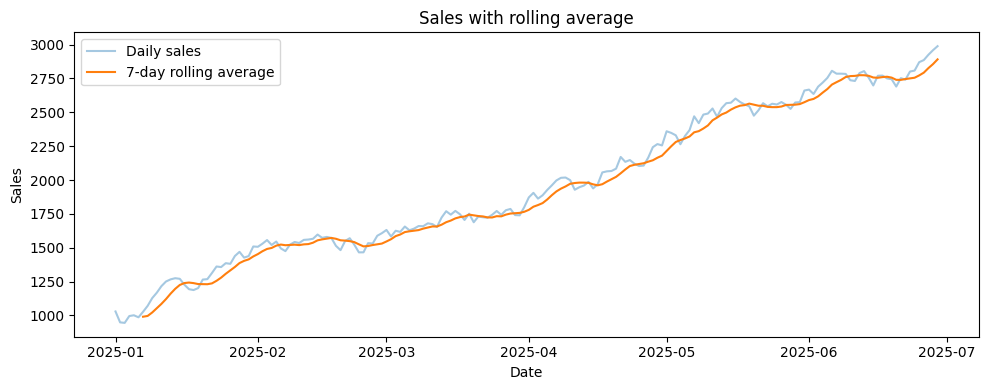

In [10]:
ts["rolling_7d"] = ts["sales"].rolling(7).mean()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(ts["date"], ts["sales"], alpha=0.4, label="Daily sales")
ax.plot(ts["date"], ts["rolling_7d"], label="7-day rolling average")

ax.set_title("Sales with rolling average")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()

fig.tight_layout()
plt.show()

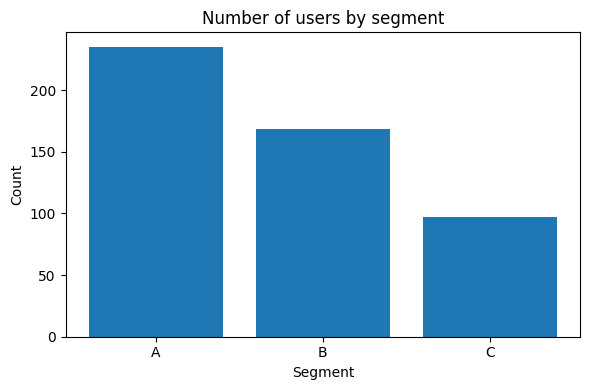

In [11]:
segment_counts = df["segment"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(segment_counts.index, segment_counts.values)

ax.set_title("Number of users by segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Count")

fig.tight_layout()
plt.show()

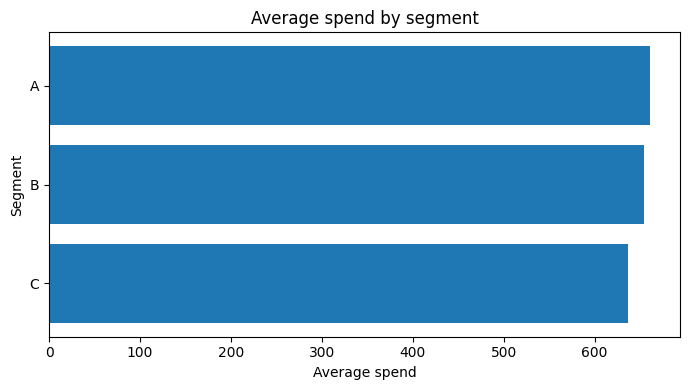

In [12]:
avg_spend = df.groupby("segment")["spend"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(avg_spend.index, avg_spend.values)

ax.set_title("Average spend by segment")
ax.set_xlabel("Average spend")
ax.set_ylabel("Segment")

fig.tight_layout()
plt.show()

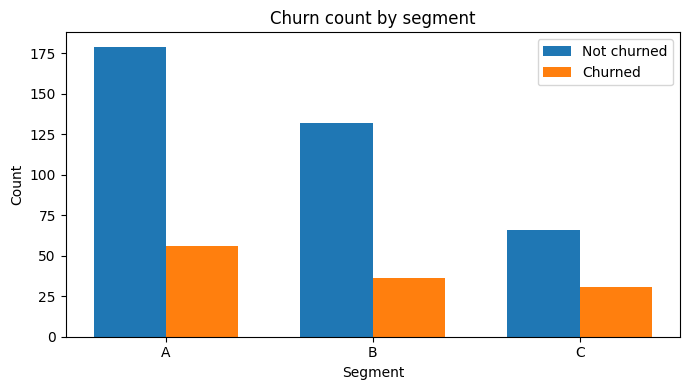

In [ ]:
summary = (
    df.groupby(["segment", "churned"])
      .size()
      .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(summary.index))
width = 0.35

ax.bar(x - width / 2, summary[0], width, label="Not churned")
ax.bar(x + width / 2, summary[1], width, label="Churned")

ax.set_xticks(x)
ax.set_xticklabels(summary.index)

ax.set_title("Churn count by segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Count")
ax.legend()

fig.tight_layout()
plt.show()

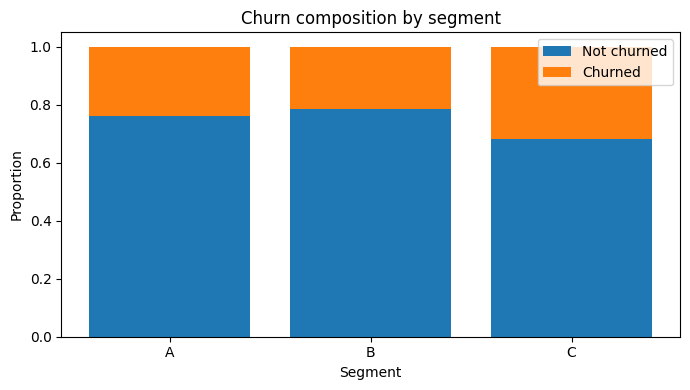

In [14]:
summary_pct = summary.div(summary.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(summary_pct.index, summary_pct[0], label="Not churned")
ax.bar(summary_pct.index, summary_pct[1], bottom=summary_pct[0], label="Churned")

ax.set_title("Churn composition by segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Proportion")
ax.legend()

fig.tight_layout()
plt.show()

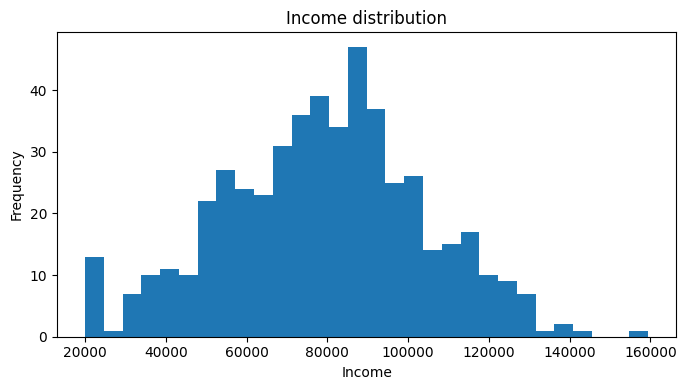

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df["income"], bins=30)

ax.set_title("Income distribution")
ax.set_xlabel("Income")
ax.set_ylabel("Frequency")

fig.tight_layout()
plt.show()

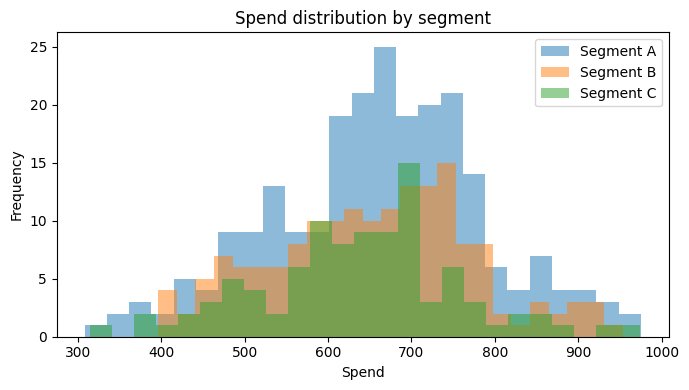

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))

for segment in df["segment"].unique():
    values = df.loc[df["segment"] == segment, "spend"]
    ax.hist(values, bins=25, alpha=0.5, label=f"Segment {segment}")

ax.set_title("Spend distribution by segment")
ax.set_xlabel("Spend")
ax.set_ylabel("Frequency")
ax.legend()

fig.tight_layout()
plt.show()

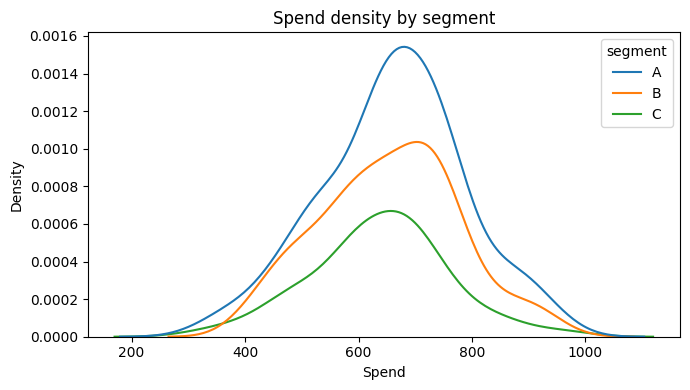

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.kdeplot(data=df, x="spend", hue="segment", ax=ax)

ax.set_title("Spend density by segment")
ax.set_xlabel("Spend")
ax.set_ylabel("Density")

fig.tight_layout()
plt.show()

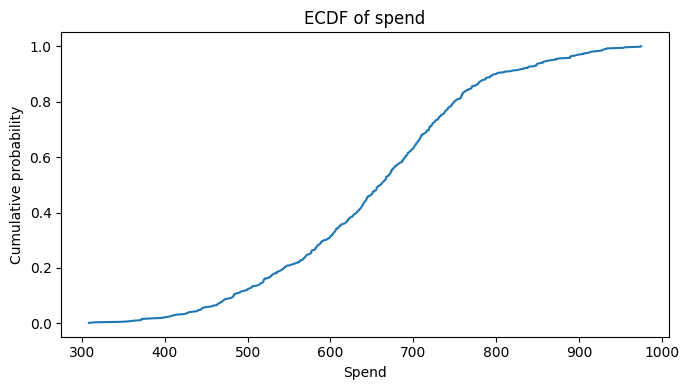

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))

x = np.sort(df["spend"])
y = np.arange(1, len(x) + 1) / len(x)

ax.plot(x, y)

ax.set_title("ECDF of spend")
ax.set_xlabel("Spend")
ax.set_ylabel("Cumulative probability")

fig.tight_layout()
plt.show()

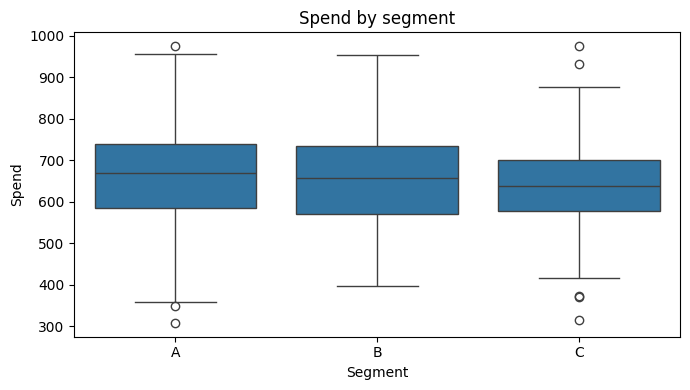

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(data=df, x="segment", y="spend", ax=ax)

ax.set_title("Spend by segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Spend")

fig.tight_layout()
plt.show()

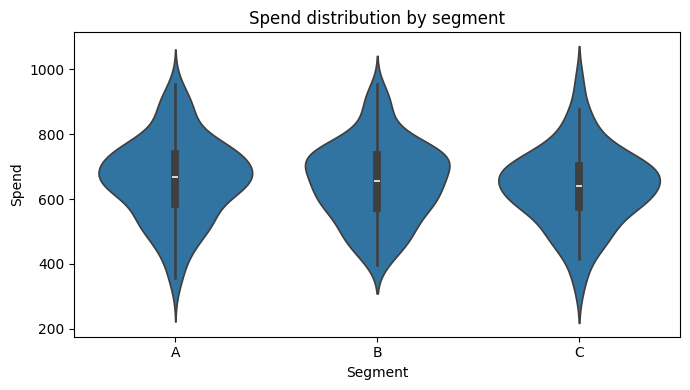

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.violinplot(data=df, x="segment", y="spend", ax=ax)

ax.set_title("Spend distribution by segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Spend")

fig.tight_layout()
plt.show()

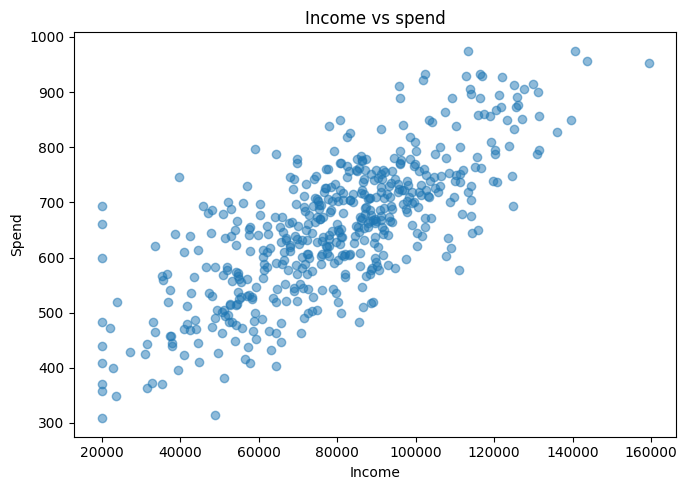

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df["income"], df["spend"], alpha=0.5)

ax.set_title("Income vs spend")
ax.set_xlabel("Income")
ax.set_ylabel("Spend")

fig.tight_layout()
plt.show()

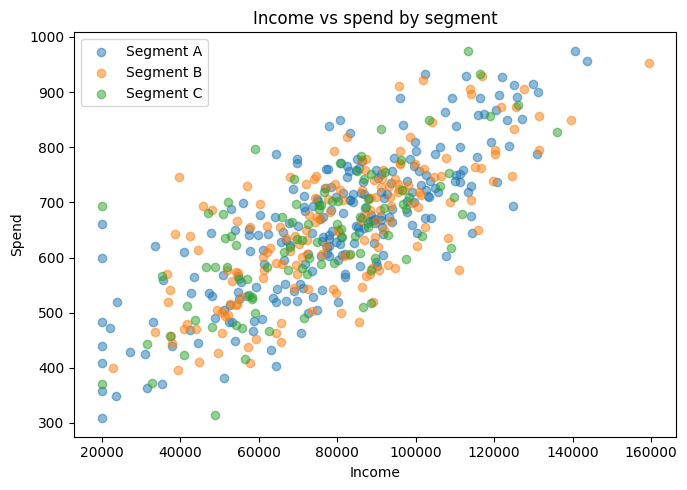

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))

for segment in df["segment"].unique():
    temp = df[df["segment"] == segment]
    ax.scatter(temp["income"], temp["spend"], alpha=0.5, label=f"Segment {segment}")

ax.set_title("Income vs spend by segment")
ax.set_xlabel("Income")
ax.set_ylabel("Spend")
ax.legend()

fig.tight_layout()
plt.show()

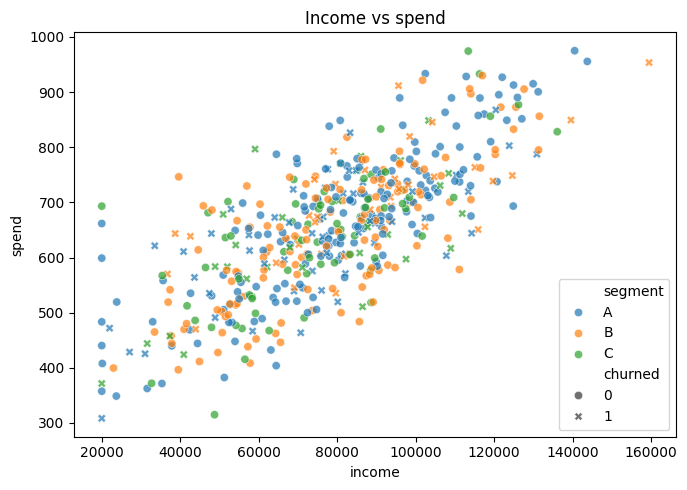

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="income",
    y="spend",
    hue="segment",
    style="churned",
    alpha=0.7,
    ax=ax
)

ax.set_title("Income vs spend")

fig.tight_layout()
plt.show()

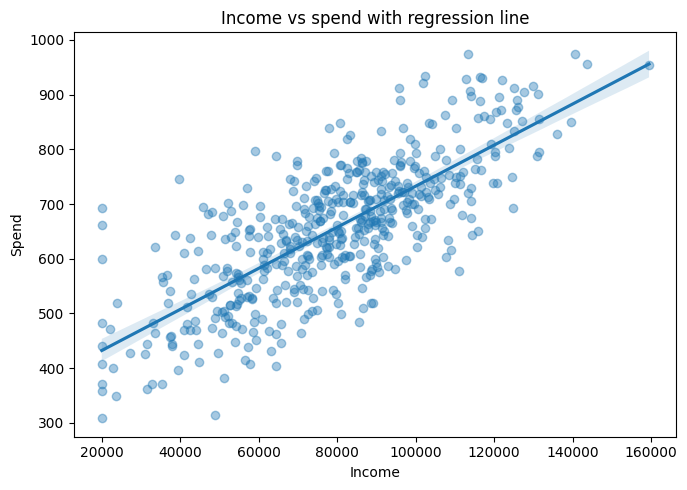

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.regplot(data=df, x="income", y="spend", scatter_kws={"alpha": 0.4}, ax=ax)

ax.set_title("Income vs spend with regression line")
ax.set_xlabel("Income")
ax.set_ylabel("Spend")

fig.tight_layout()
plt.show()

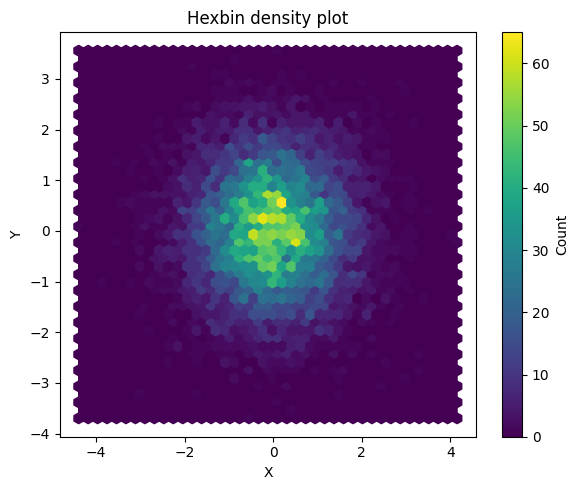

In [25]:
big_n = 10000

big_df = pd.DataFrame({
    "x": rng.normal(0, 1, big_n),
    "y": rng.normal(0, 1, big_n)
})

fig, ax = plt.subplots(figsize=(6, 5))

hb = ax.hexbin(big_df["x"], big_df["y"], gridsize=40)
fig.colorbar(hb, ax=ax, label="Count")

ax.set_title("Hexbin density plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")

fig.tight_layout()
plt.show()

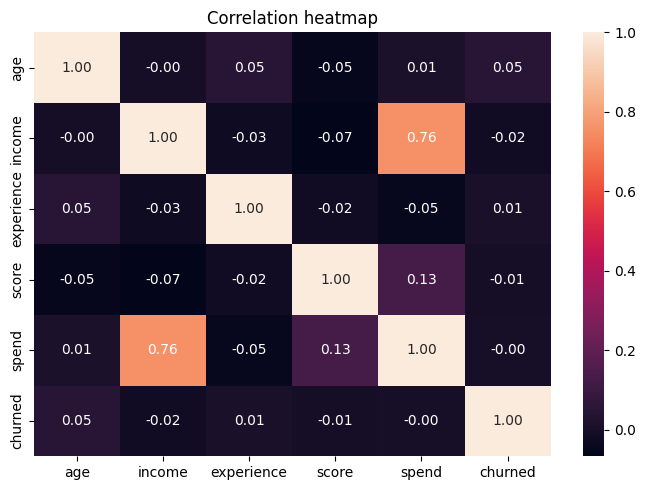

In [26]:
numeric_cols = ["age", "income", "experience", "score", "spend", "churned"]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(corr, annot=True, fmt=".2f", ax=ax)

ax.set_title("Correlation heatmap")

fig.tight_layout()
plt.show()

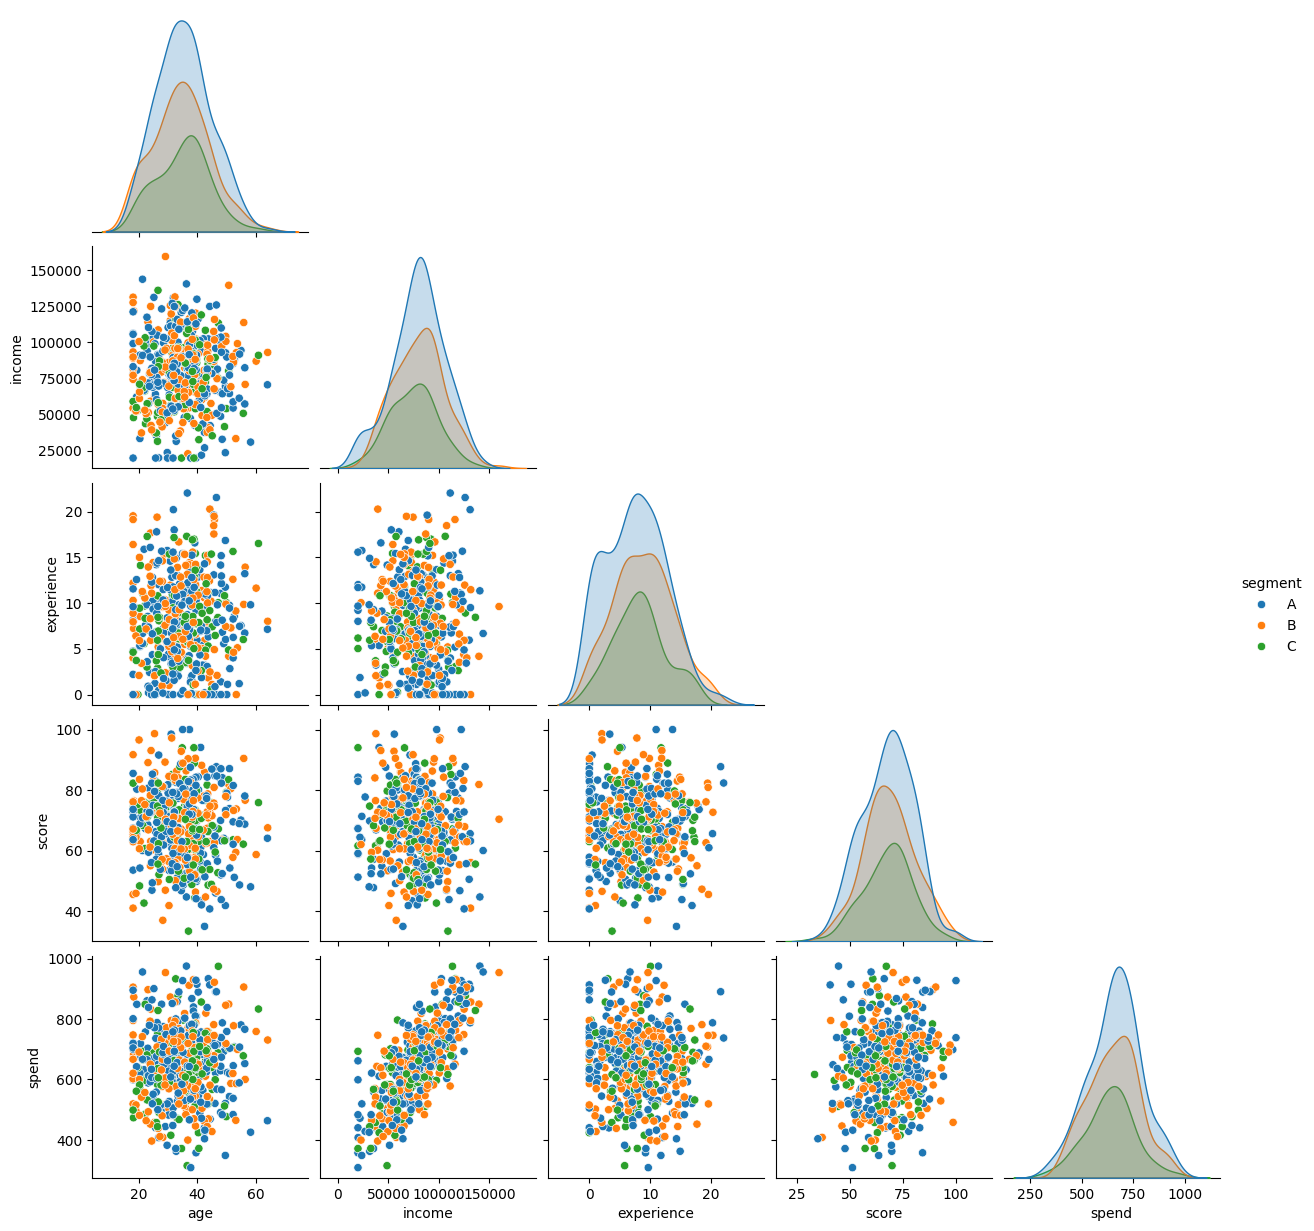

In [27]:
sns.pairplot(
    df[["age", "income", "experience", "score", "spend", "segment"]],
    hue="segment",
    corner=True
)

plt.show()

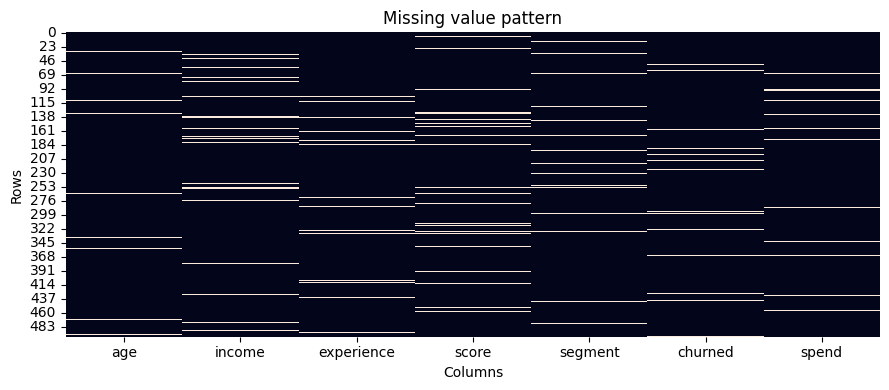

In [28]:
df_missing = df.copy()

mask = rng.random(df_missing.shape) < 0.05
df_missing = df_missing.mask(mask)

missing_matrix = df_missing.isna()

fig, ax = plt.subplots(figsize=(9, 4))

sns.heatmap(missing_matrix, cbar=False, ax=ax)

ax.set_title("Missing value pattern")
ax.set_xlabel("Columns")
ax.set_ylabel("Rows")

fig.tight_layout()
plt.show()

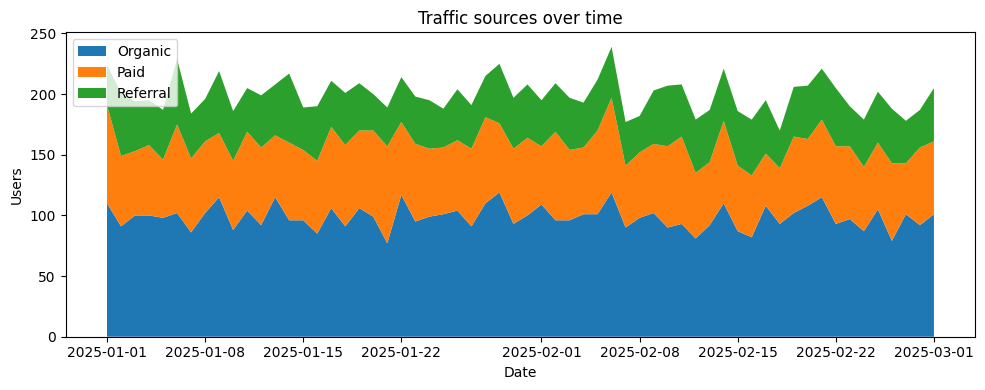

In [29]:
dates = pd.date_range("2025-01-01", periods=60, freq="D")

area_df = pd.DataFrame({
    "date": dates,
    "organic": rng.poisson(100, len(dates)),
    "paid": rng.poisson(60, len(dates)),
    "referral": rng.poisson(40, len(dates)),
})

fig, ax = plt.subplots(figsize=(10, 4))

ax.stackplot(
    area_df["date"],
    area_df["organic"],
    area_df["paid"],
    area_df["referral"],
    labels=["Organic", "Paid", "Referral"]
)

ax.set_title("Traffic sources over time")
ax.set_xlabel("Date")
ax.set_ylabel("Users")
ax.legend(loc="upper left")

fig.tight_layout()
plt.show()

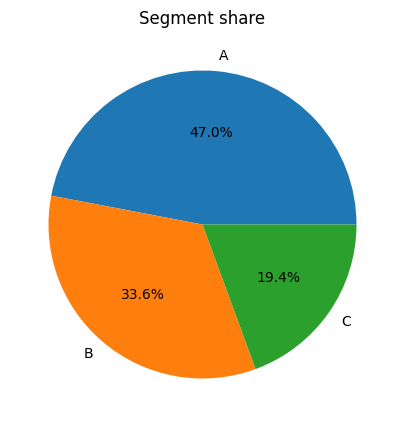

In [30]:
counts = df["segment"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%")
ax.set_title("Segment share")

plt.show()

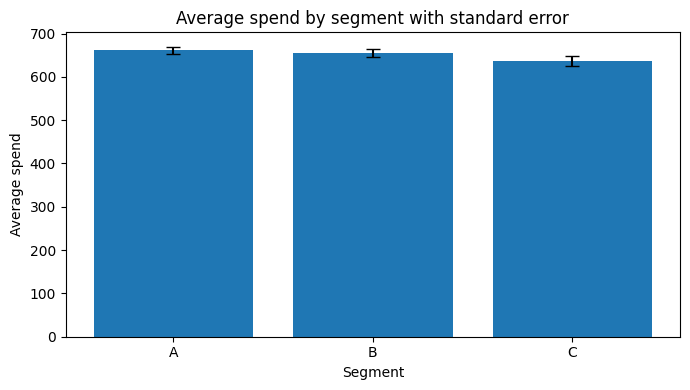

In [31]:
summary = (
    df.groupby("segment")["spend"]
      .agg(["mean", "std", "count"])
)

summary["sem"] = summary["std"] / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(summary.index, summary["mean"], yerr=summary["sem"], capsize=5)

ax.set_title("Average spend by segment with standard error")
ax.set_xlabel("Segment")
ax.set_ylabel("Average spend")

fig.tight_layout()
plt.show()

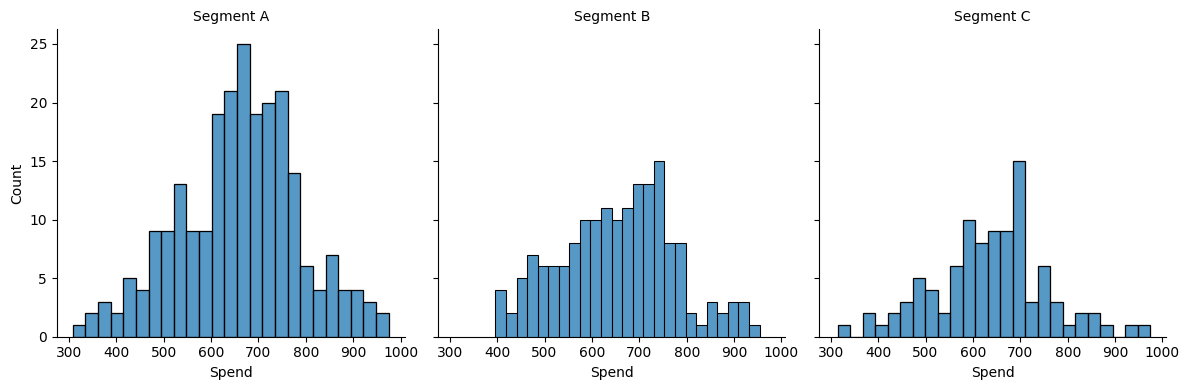

In [32]:
g = sns.FacetGrid(df, col="segment", height=4, aspect=1)

g.map_dataframe(sns.histplot, x="spend", bins=25)

g.set_axis_labels("Spend", "Count")
g.set_titles("Segment {col_name}")

plt.show()

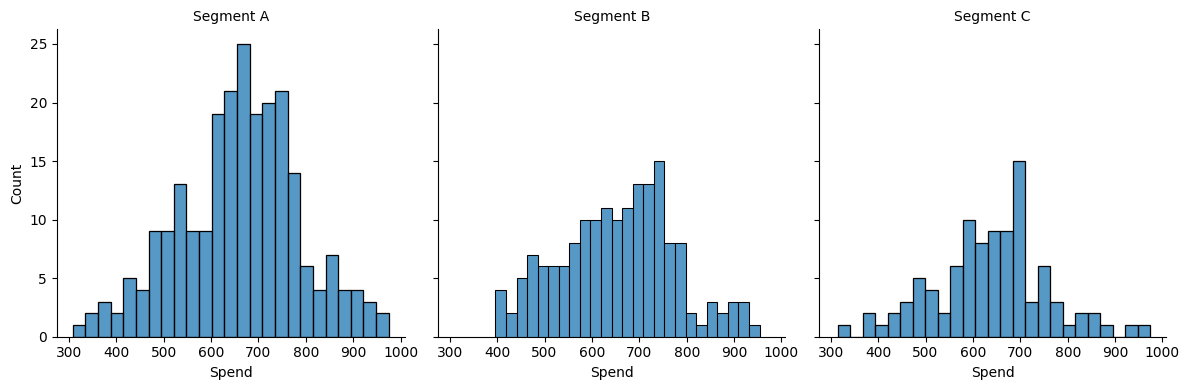

In [33]:
g = sns.FacetGrid(df, col="segment", height=4, aspect=1)

g.map_dataframe(sns.histplot, x="spend", bins=25)

g.set_axis_labels("Spend", "Count")
g.set_titles("Segment {col_name}")

plt.show()

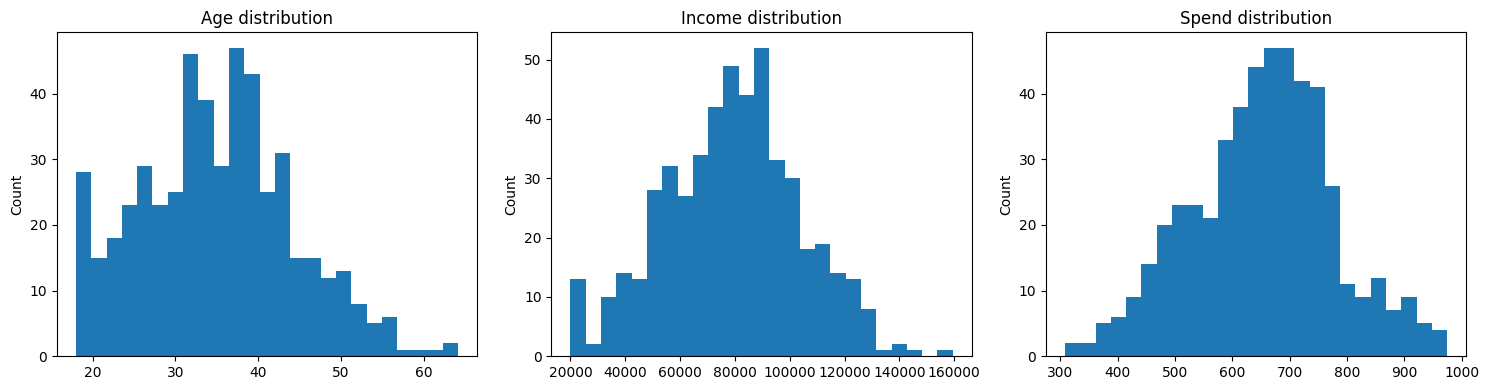

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["age"], bins=25)
axes[0].set_title("Age distribution")

axes[1].hist(df["income"], bins=25)
axes[1].set_title("Income distribution")

axes[2].hist(df["spend"], bins=25)
axes[2].set_title("Spend distribution")

for ax in axes:
    ax.set_ylabel("Count")

fig.tight_layout()
plt.show()

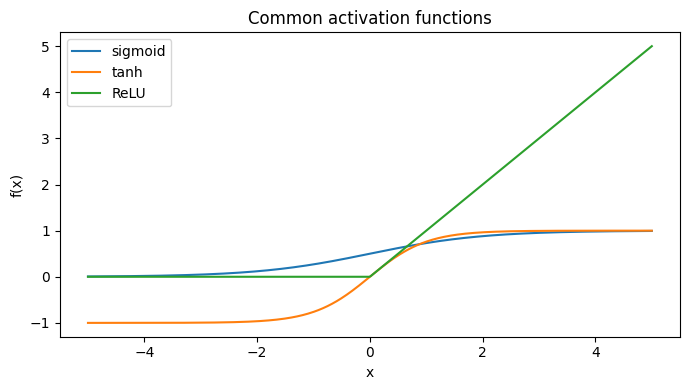

In [36]:
x = np.linspace(-5, 5, 500)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x, sigmoid, label="sigmoid")
ax.plot(x, tanh, label="tanh")
ax.plot(x, relu, label="ReLU")

ax.set_title("Common activation functions")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend()

fig.tight_layout()
plt.show()

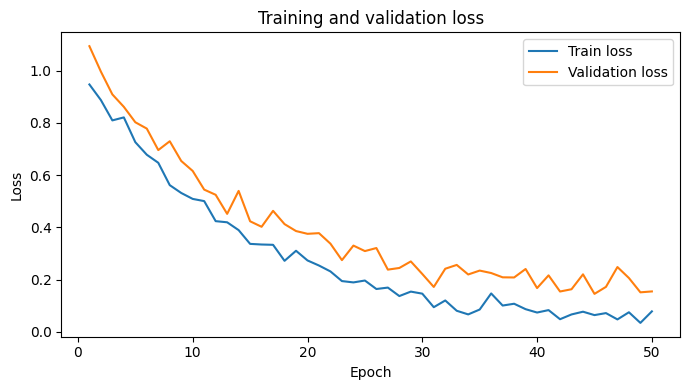

In [37]:
epochs = np.arange(1, 51)

train_loss = np.exp(-epochs / 15) + rng.normal(0, 0.02, len(epochs))
val_loss = np.exp(-epochs / 13) + 0.15 + rng.normal(0, 0.03, len(epochs))

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(epochs, train_loss, label="Train loss")
ax.plot(epochs, val_loss, label="Validation loss")

ax.set_title("Training and validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

fig.tight_layout()
plt.show()

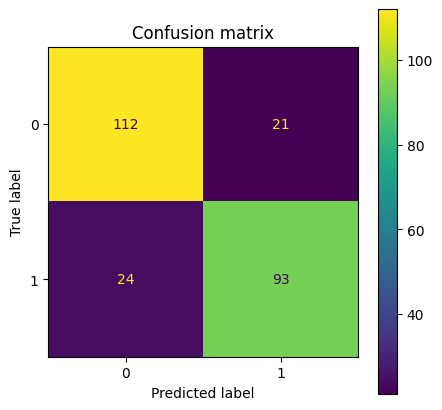

In [38]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)

ax.set_title("Confusion matrix")

plt.show()

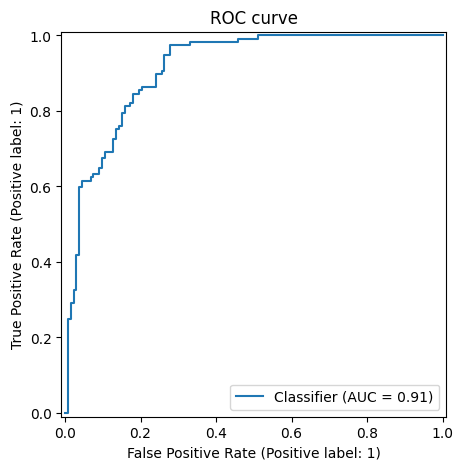

In [39]:
from sklearn.metrics import RocCurveDisplay

y_score = model.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(y_test, y_score, ax=ax)

ax.set_title("ROC curve")

plt.show()

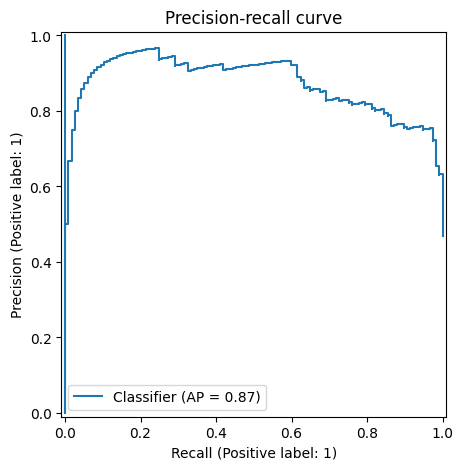

In [40]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(6, 5))

PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=ax)

ax.set_title("Precision-recall curve")

plt.show()

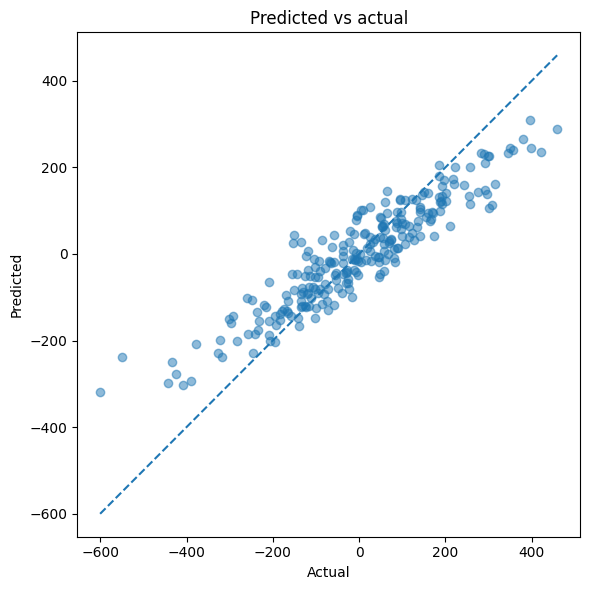

In [41]:
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X, y = make_regression(
    n_samples=1000,
    n_features=8,
    noise=20,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

reg = RandomForestRegressor(random_state=42)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

ax.set_title("Predicted vs actual")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")

fig.tight_layout()
plt.show()

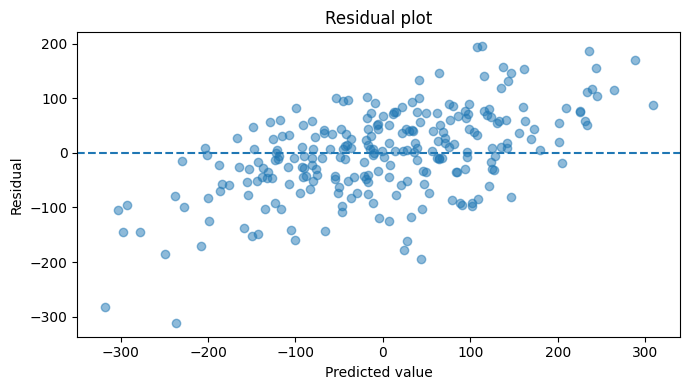

In [42]:
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(y_pred, residuals, alpha=0.5)
ax.axhline(0, linestyle="--")

ax.set_title("Residual plot")
ax.set_xlabel("Predicted value")
ax.set_ylabel("Residual")

fig.tight_layout()
plt.show()

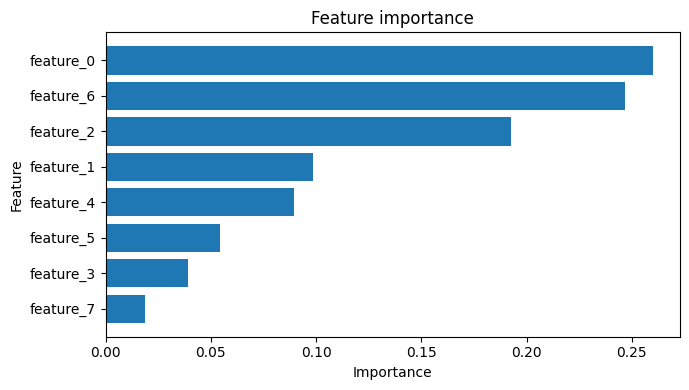

In [43]:
feature_names = [f"feature_{i}" for i in range(X.shape[1])]
importances = reg.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance")

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(importance_df["feature"], importance_df["importance"])

ax.set_title("Feature importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

fig.tight_layout()
plt.show()

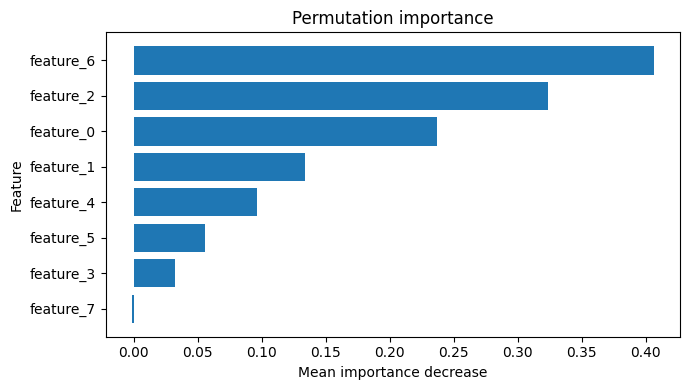

In [44]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    reg,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": result.importances_mean
}).sort_values("importance")

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(perm_df["feature"], perm_df["importance"])

ax.set_title("Permutation importance")
ax.set_xlabel("Mean importance decrease")
ax.set_ylabel("Feature")

fig.tight_layout()
plt.show()

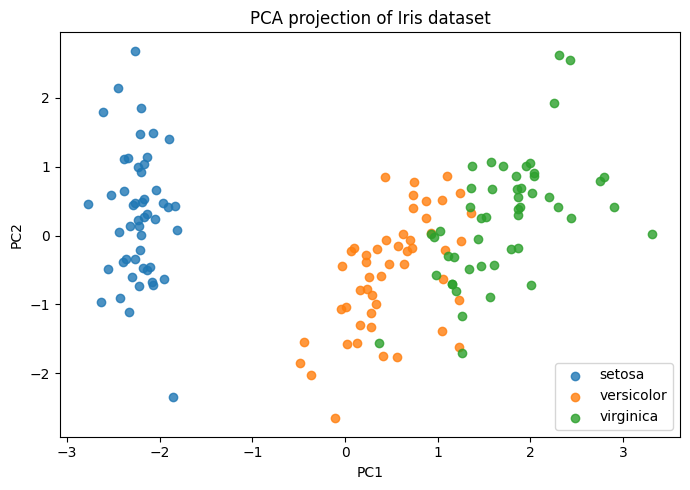

In [45]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data
y = iris.target

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1],
    "target": y
})

fig, ax = plt.subplots(figsize=(7, 5))

for label in np.unique(y):
    temp = pca_df[pca_df["target"] == label]
    ax.scatter(temp["pc1"], temp["pc2"], label=iris.target_names[label], alpha=0.8)

ax.set_title("PCA projection of Iris dataset")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()

fig.tight_layout()
plt.show()

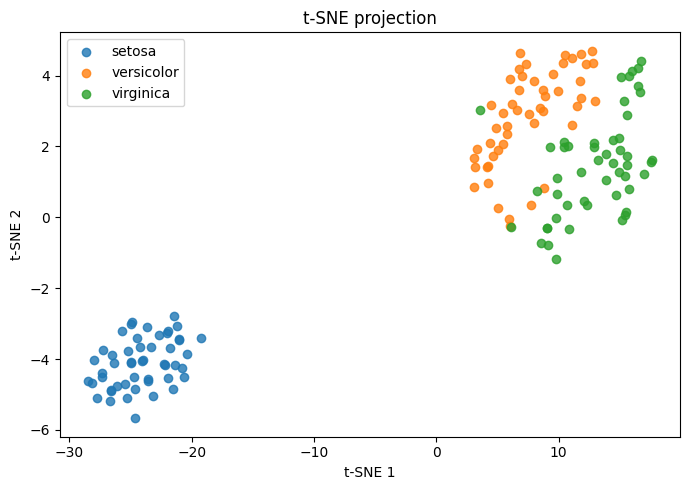

In [46]:
from sklearn.manifold import TSNE

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
).fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "target": y
})

fig, ax = plt.subplots(figsize=(7, 5))

for label in np.unique(y):
    temp = tsne_df[tsne_df["target"] == label]
    ax.scatter(temp["x"], temp["y"], label=iris.target_names[label], alpha=0.8)

ax.set_title("t-SNE projection")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()

fig.tight_layout()
plt.show()

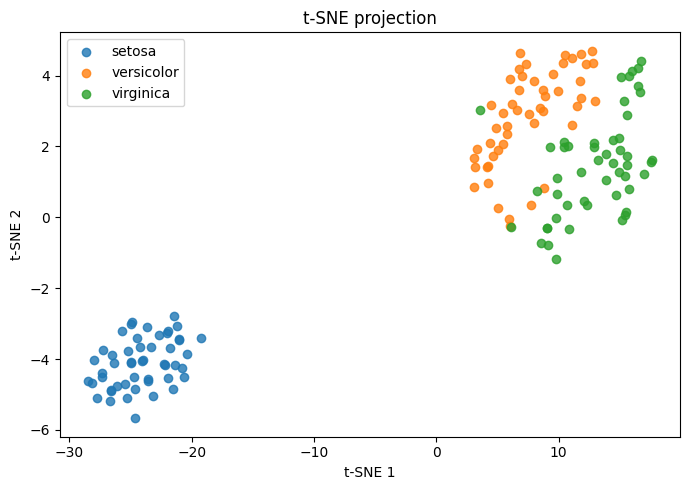

In [47]:
from sklearn.manifold import TSNE

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
).fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "target": y
})

fig, ax = plt.subplots(figsize=(7, 5))

for label in np.unique(y):
    temp = tsne_df[tsne_df["target"] == label]
    ax.scatter(temp["x"], temp["y"], label=iris.target_names[label], alpha=0.8)

ax.set_title("t-SNE projection")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()

fig.tight_layout()
plt.show()

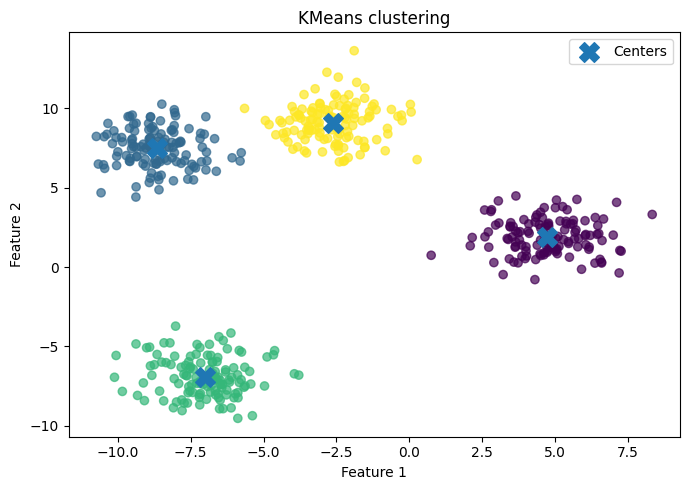

In [48]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, true_labels = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X)

fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(X[:, 0], X[:, 1], c=cluster_labels, alpha=0.7)

ax.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    label="Centers"
)

ax.set_title("KMeans clustering")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()

fig.tight_layout()
plt.show()

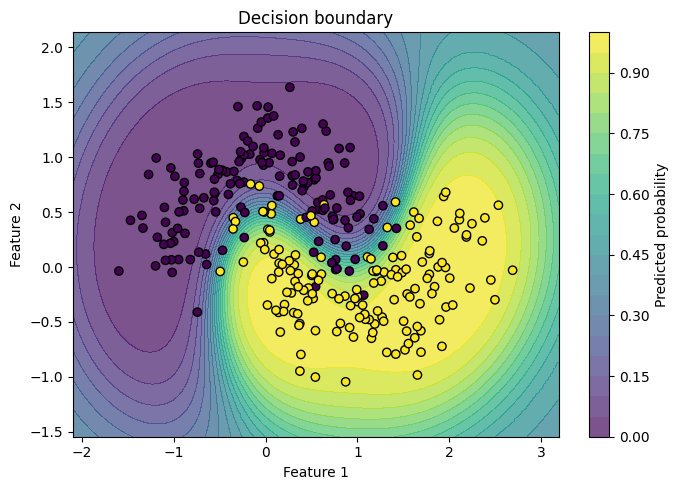

In [49]:
from sklearn.datasets import make_moons
from sklearn.svm import SVC

X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

clf = SVC(kernel="rbf", probability=True)
clf.fit(X, y)

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
probs = clf.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5))

contour = ax.contourf(xx, yy, probs, levels=20, alpha=0.7)
fig.colorbar(contour, ax=ax, label="Predicted probability")

ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")

ax.set_title("Decision boundary")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

fig.tight_layout()
plt.show()

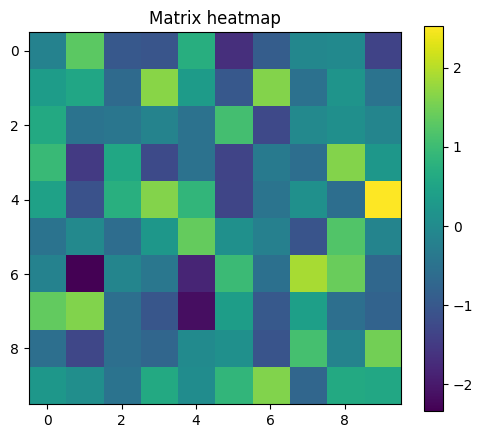

In [50]:
matrix = rng.normal(size=(10, 10))

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(matrix)
fig.colorbar(im, ax=ax)

ax.set_title("Matrix heatmap")

plt.show()

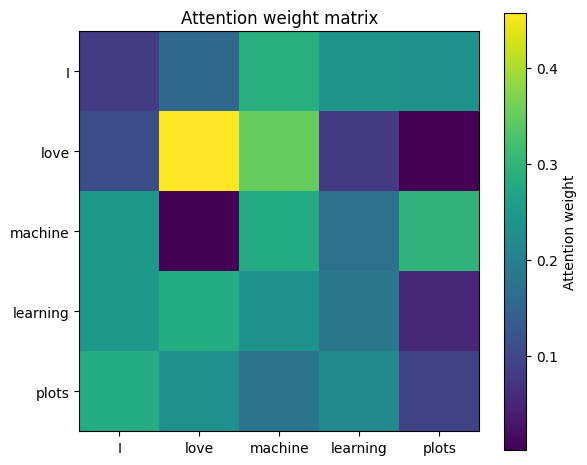

In [51]:
tokens = ["I", "love", "machine", "learning", "plots"]

attention = rng.random((len(tokens), len(tokens)))
attention = attention / attention.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(attention)

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens)
ax.set_yticklabels(tokens)

fig.colorbar(im, ax=ax, label="Attention weight")

ax.set_title("Attention weight matrix")

fig.tight_layout()
plt.show()

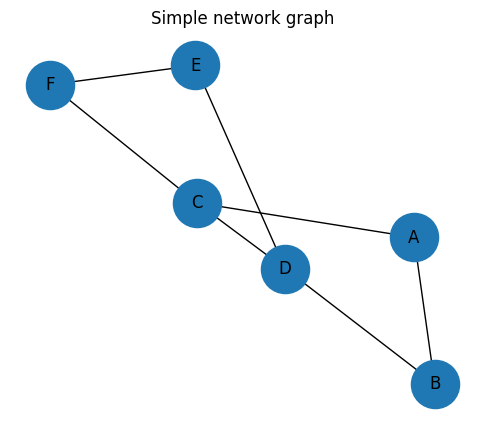

In [52]:
import networkx as nx

G = nx.Graph()

edges = [
    ("A", "B"),
    ("A", "C"),
    ("B", "D"),
    ("C", "D"),
    ("D", "E"),
    ("E", "F"),
    ("C", "F")
]

G.add_edges_from(edges)

pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(6, 5))

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=1200,
    ax=ax
)

ax.set_title("Simple network graph")
ax.axis("off")

plt.show()

In [55]:
import plotly.express as px

fig = px.scatter(
    df,
    x="income",
    y="spend",
    color="segment",
    size="score",
    hover_data=["age", "experience", "churned"],
    title="Interactive income vs spend"
)

fig.show()

In [56]:
fig = px.line(
    ts,
    x="date",
    y="sales",
    title="Interactive sales trend"
)

fig.show()

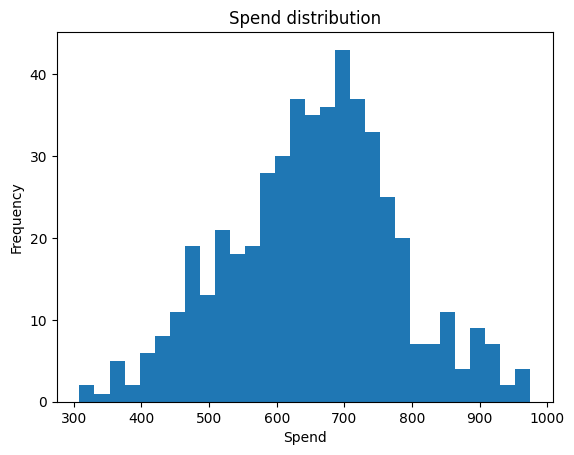

In [57]:
df["spend"].plot(kind="hist", bins=30, title="Spend distribution")
plt.xlabel("Spend")
plt.show()

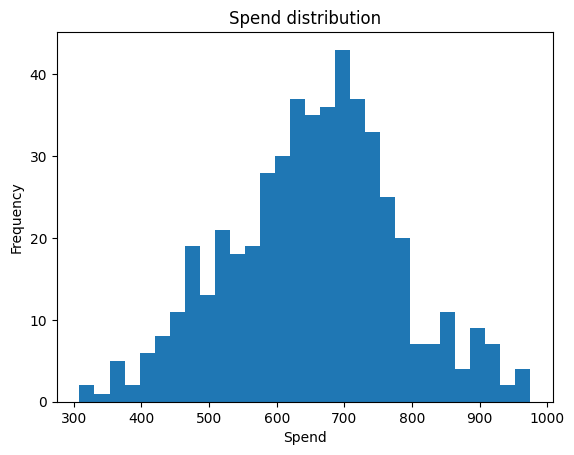

In [58]:
df["spend"].plot(kind="hist", bins=30, title="Spend distribution")
plt.xlabel("Spend")
plt.show()